# Prediksi Pembangkitan Energi Surya Berbasis Panel Fotovoltaik
**Pembelajaran Mesin — S1 Sains Data, UNESA**

Dataset: solarPV.csv — data historis pembangkitan energi surya per jam dari 179+ wilayah di Eropa, Afrika Utara, dan Timur Tengah (sumber: DTU Data / PVGIS).

Alur notebook :
1. Load Data
2. Exploratory Data Analysis (EDA)
3. Data Cleaning
4. Feature Engineering
   - 4.1 Feature Selection (F-Score & Mutual Information)
   - 4.2 Reduksi Dimensi: PCA dan LDA
5. Pelatihan Model (Random Forest, XGBoost, LSTM)
   - Plot Split Data Train & Test (XGBoost)
6. Evaluasi dan Perbandingan Model
7. Scaling ke Seluruh Wilayah
   - 7.1 Actual vs Predicted XGBoost — Multi-Wilayah
8. Deteksi Anomali
9. Multi-Step Forecasting
10. Export Hasil

## 1. Load Data

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/content/solarPV.csv', on_bad_lines='skip')

print("Shape:", df.shape)
print("\nSample kolom wilayah:", df.columns.tolist()[1:6])
df.head()

Shape: (197469, 180)

Sample kolom wilayah: ['AL00', 'AT00', 'AT01', 'AT02', 'AT03']


,Time,AL00,AT00,AT01,AT02,AT03,BA00,BE00,BE01,BE02,...,UA01,UA02,UK00,UK01,UK02,UK03,UK04,UK05,UKNI,XK00
0,01-Jan-1982 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,01-Jan-1982 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,01-Jan-1982 02:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,01-Jan-1982 03:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,01-Jan-1982 04:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Exploratory Data Analysis (EDA)



In [31]:
# Konversi kolom Time ke datetime dan jadikan index
df['Time'] = pd.to_datetime(df['Time'], errors='coerce')
df = df.dropna(subset=['Time'])
df.set_index('Time', inplace=True)

print("Rentang waktu :", df.index.min(), "hingga", df.index.max())
print("Jumlah baris  :", len(df))
print("Jumlah wilayah:", df.shape[1])

Rentang waktu : 1982-01-01 00:00:00 hingga 2004-07-11 20:00:00
Jumlah baris  : 197469
Jumlah wilayah: 179


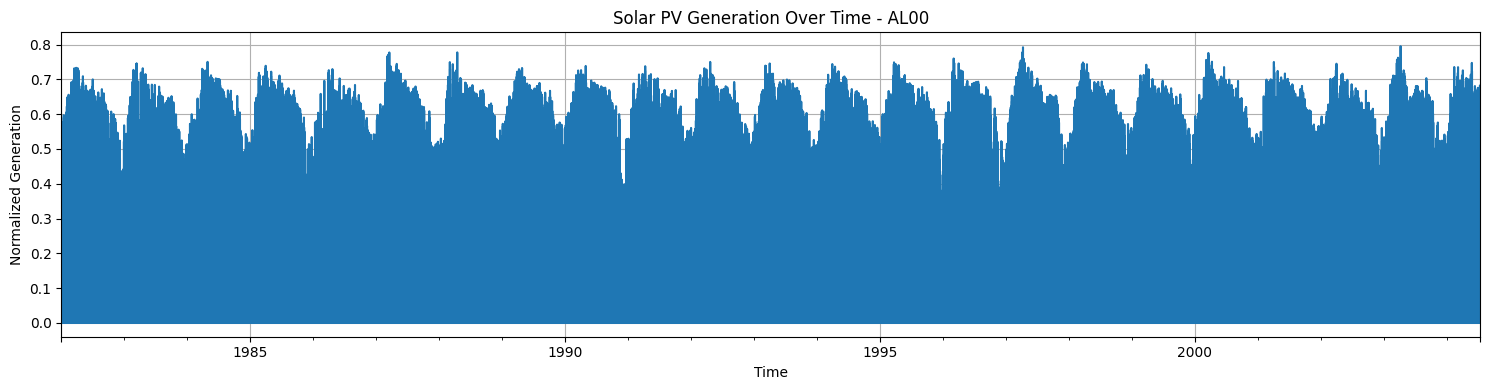

In [32]:
# Tren deret waktu - AL00 (Albania) sebagai contoh
plt.figure(figsize=(15, 4))
df['AL00'].plot()
plt.title('Solar PV Generation Over Time - AL00')
plt.ylabel('Normalized Generation')
plt.xlabel('Time')
plt.grid(True)
plt.tight_layout()
plt.show()

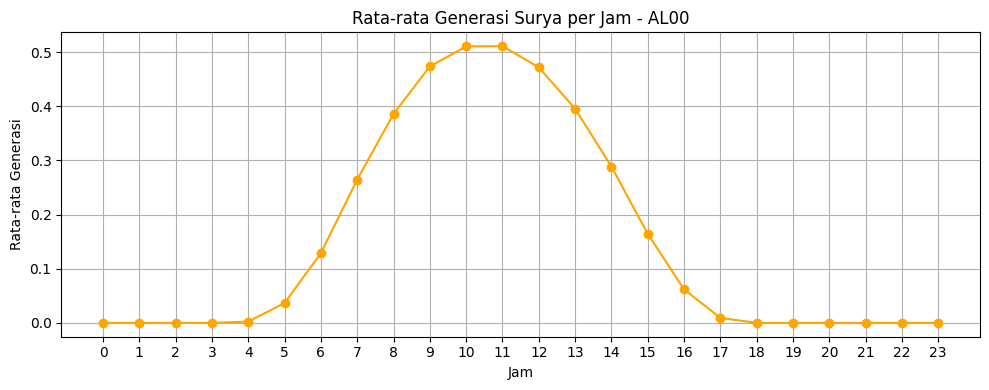

In [33]:
# Pola harian: rata-rata generasi per jam
temp = df[['AL00']].copy()
temp['hour'] = temp.index.hour
hourly_avg = temp.groupby('hour')['AL00'].mean()

plt.figure(figsize=(10, 4))
hourly_avg.plot(marker='o', color='orange')
plt.title('Rata-rata Generasi Surya per Jam - AL00')
plt.xlabel('Jam')
plt.ylabel('Rata-rata Generasi')
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.show()

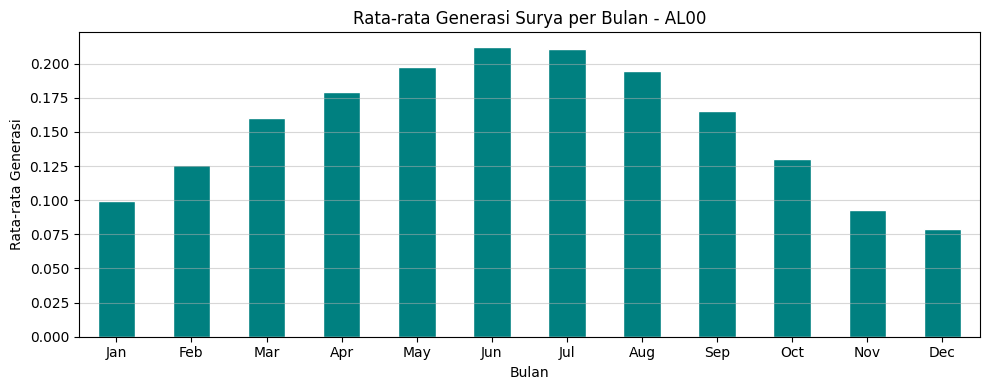

In [34]:
# Pola musiman: rata-rata generasi per bulan
temp['month'] = temp.index.month
monthly_avg = temp.groupby('month')['AL00'].mean()

month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
plt.figure(figsize=(10, 4))
monthly_avg.plot(kind='bar', color='teal', edgecolor='white')
plt.title('Rata-rata Generasi Surya per Bulan - AL00')
plt.xlabel('Bulan')
plt.ylabel('Rata-rata Generasi')
plt.xticks(range(12), month_labels, rotation=0)
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

In [35]:
# Cek missing values
missing = df.isnull().sum().sort_values(ascending=False)
print("Top 10 kolom dengan missing values:")
print(missing.head(10))
print(f"\nTotal sel kosong: {df.isnull().sum().sum()}")

Top 10 kolom dengan missing values:
AL00    1
AT00    1
AT01    1
AT02    1
AT03    1
BA00    1
BE00    1
BE01    1
BE02    1
BE03    1
dtype: int64

Total sel kosong: 179


## 3. Data Cleaning

Missing values diisi dengan 0, yang secara domain berarti tidak ada produksi energi pada periode tersebut.

In [36]:
df_clean = df.fillna(0)

print("Missing values setelah cleaning:", df_clean.isnull().sum().sum())
print("Shape setelah cleaning         :", df_clean.shape)

Missing values setelah cleaning: 0
Shape setelah cleaning         : (197469, 179)


## 4. Feature Engineering

Fitur temporal diekstraksi dari indeks datetime. Lag feature (lag_1) — nilai generasi 1 jam sebelumnya — ditambahkan pada tahap modeling untuk menangkap dependensi autoregresif.

In [37]:
df_clean['hour']        = df_clean.index.hour
df_clean['day']         = df_clean.index.day
df_clean['month']       = df_clean.index.month
df_clean['day_of_week'] = df_clean.index.dayofweek

base_features = ['hour', 'day', 'month', 'day_of_week']

print("Fitur temporal berhasil dibuat:", base_features)
print("Shape dataset                 :", df_clean.shape)

Fitur temporal berhasil dibuat: ['hour', 'day', 'month', 'day_of_week']
Shape dataset                 : (197469, 183)


## 4.1 Feature Selection

Seleksi fitur dilakukan menggunakan dua metode statistik: **F-Score Regression** (mengukur korelasi linear antara fitur dan target) dan **Mutual Information** (mengukur dependensi non-linear). Fitur dengan skor tertinggi diprioritaskan dalam pelatihan model.

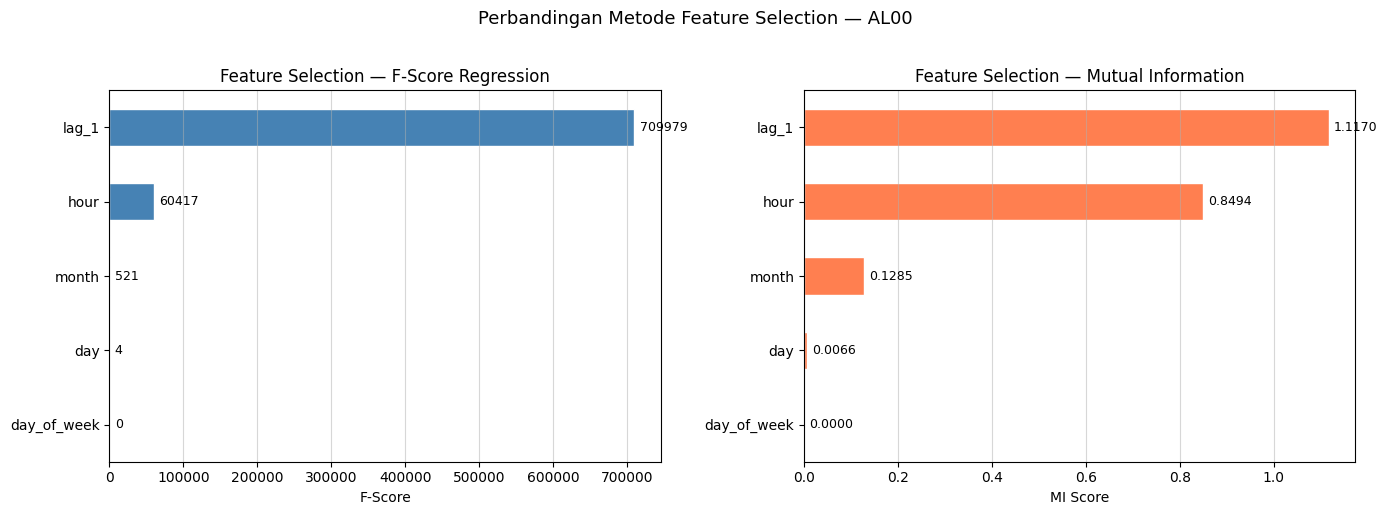

Ranking Fitur (F-Score):
               F-Score
lag_1        709978.79
hour          60417.37
month           521.16
day               3.86
day_of_week       0.29

Ranking Fitur (Mutual Information):
             MI Score
lag_1          1.1170
hour           0.8494
month          0.1285
day            0.0066
day_of_week    0.0000

✅ Top-3 fitur terpilih (MI): ['lag_1', 'hour', 'month']


In [38]:
# ============================================================
# FEATURE SELECTION: F-Score Regression & Mutual Information
# ============================================================
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.preprocessing import StandardScaler

# Siapkan data dengan lag feature untuk seleksi
fs_data = df_clean[['AL00'] + base_features].copy()
fs_data['AL00'] = pd.to_numeric(fs_data['AL00'], errors='coerce').fillna(0)
fs_data['lag_1'] = fs_data['AL00'].shift(1).fillna(0)
fs_data = fs_data[(fs_data['hour'] >= 6) & (fs_data['hour'] <= 20)]

all_features = base_features + ['lag_1']
X_fs = fs_data[all_features]
y_fs = fs_data['AL00']

# --- F-Score Regression ---
selector_f = SelectKBest(score_func=f_regression, k='all')
selector_f.fit(X_fs, y_fs)
f_scores = pd.Series(selector_f.scores_, index=all_features).sort_values(ascending=True)

# --- Mutual Information ---
mi_scores_arr = mutual_info_regression(X_fs, y_fs, random_state=42)
mi_series = pd.Series(mi_scores_arr, index=all_features).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

f_scores.plot(kind='barh', color='steelblue', edgecolor='white', ax=axes[0])
axes[0].set_title('Feature Selection — F-Score Regression', fontsize=12)
axes[0].set_xlabel('F-Score')
for i, v in enumerate(f_scores.values):
    axes[0].text(v + f_scores.max()*0.01, i, f'{v:.0f}', va='center', fontsize=9)
axes[0].grid(axis='x', alpha=0.5)

mi_series.plot(kind='barh', color='coral', edgecolor='white', ax=axes[1])
axes[1].set_title('Feature Selection — Mutual Information', fontsize=12)
axes[1].set_xlabel('MI Score')
for i, v in enumerate(mi_series.values):
    axes[1].text(v + mi_series.max()*0.01, i, f'{v:.4f}', va='center', fontsize=9)
axes[1].grid(axis='x', alpha=0.5)

plt.suptitle('Perbandingan Metode Feature Selection — AL00', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

top_features = mi_series.sort_values(ascending=False).head(3).index.tolist()
print("Ranking Fitur (F-Score):")
print(f_scores.sort_values(ascending=False).to_frame('F-Score').round(2).to_string())
print("\nRanking Fitur (Mutual Information):")
print(mi_series.sort_values(ascending=False).to_frame('MI Score').round(4).to_string())
print(f"\n✅ Top-3 fitur terpilih (MI): {top_features}")

## 4.2 Reduksi Dimensi: PCA dan LDA

**PCA (Principal Component Analysis)** — metode unsupervised yang memproyeksikan fitur ke arah varians maksimum.  
**LDA (Linear Discriminant Analysis)** — metode supervised yang memaksimalkan separasi antar kelas (produksi tinggi vs rendah).

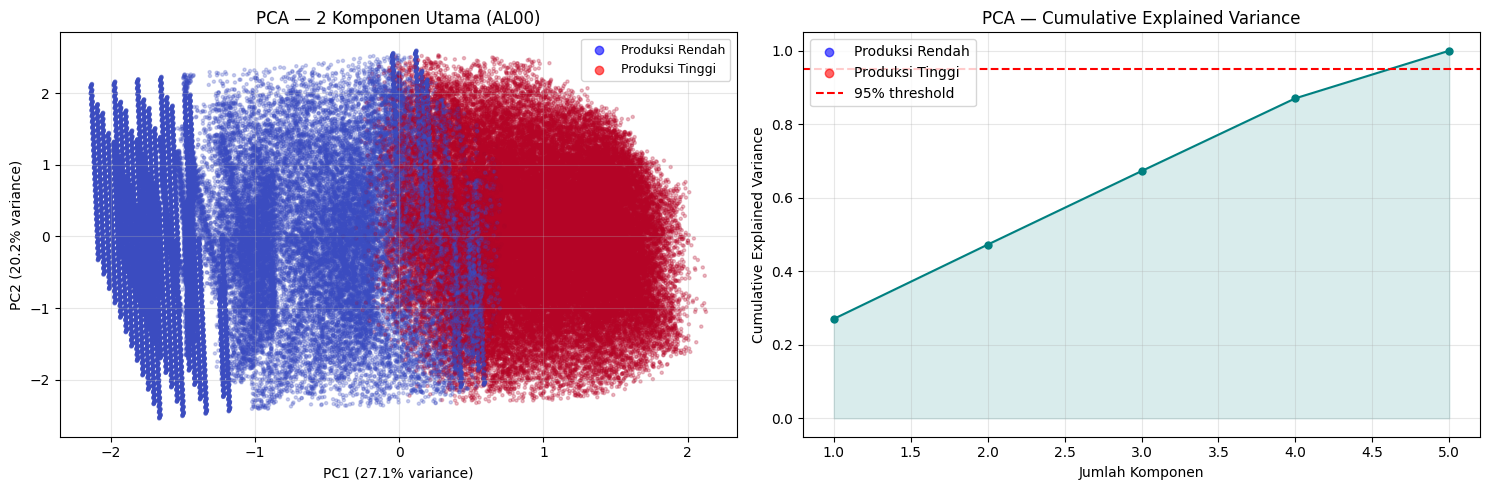

PC1 explains : 27.06%
PC2 explains : 20.20%
Total (2 PC) : 47.26%


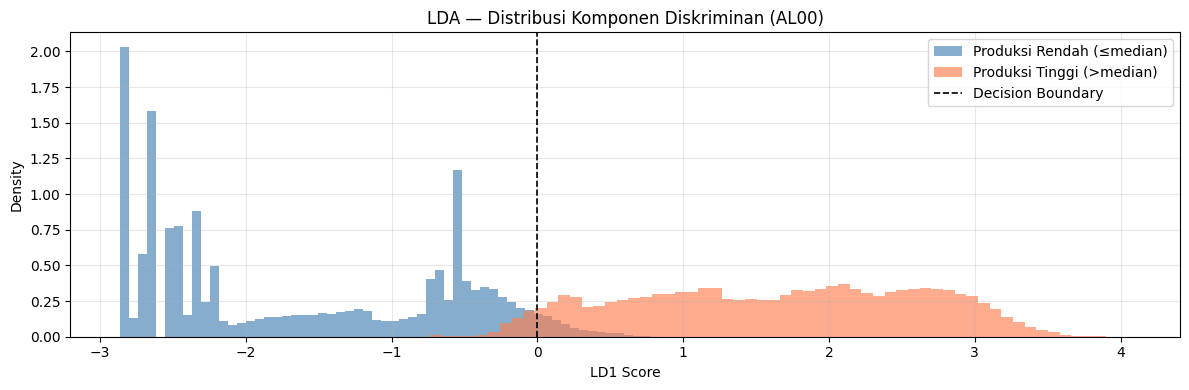


LDA Explained variance ratio : [1.]
Separasi kelas (gap antar mean LD1): 3.2538


In [39]:
# ============================================================
# PCA DAN LDA
# ============================================================
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Siapkan data (reuse fs_data dari Feature Selection)
X_scaled_dim = StandardScaler().fit_transform(X_fs.values)
median_val = y_fs.median()
y_dim = (y_fs > median_val).astype(int).values

# ── PCA ──────────────────────────────────────────────────────
pca2 = PCA(n_components=2)
X_pca = pca2.fit_transform(X_scaled_dim)

pca_full = PCA().fit(X_scaled_dim)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                           c=y_dim, cmap='coolwarm', alpha=0.25, s=5)
axes[0].set_title('PCA — 2 Komponen Utama (AL00)', fontsize=12)
axes[0].set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)')
legend_handles = [plt.scatter([], [], c='blue', alpha=0.6, label='Produksi Rendah'),
                  plt.scatter([], [], c='red',  alpha=0.6, label='Produksi Tinggi')]
axes[0].legend(handles=legend_handles, fontsize=9)
axes[0].grid(alpha=0.3)

axes[1].plot(range(1, len(cum_var)+1), cum_var, marker='o', color='teal', markersize=5)
axes[1].axhline(0.95, color='red', linestyle='--', label='95% threshold')
axes[1].fill_between(range(1, len(cum_var)+1), cum_var, alpha=0.15, color='teal')
axes[1].set_title('PCA — Cumulative Explained Variance', fontsize=12)
axes[1].set_xlabel('Jumlah Komponen')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"PC1 explains : {pca2.explained_variance_ratio_[0]*100:.2f}%")
print(f"PC2 explains : {pca2.explained_variance_ratio_[1]*100:.2f}%")
print(f"Total (2 PC) : {sum(pca2.explained_variance_ratio_)*100:.2f}%")

# ── LDA ──────────────────────────────────────────────────────
lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit_transform(X_scaled_dim, y_dim)

plt.figure(figsize=(12, 4))
for label, color, name in [(0, 'steelblue', 'Produksi Rendah (≤median)'),
                            (1, 'coral',     'Produksi Tinggi (>median)')]:
    mask = y_dim == label
    plt.hist(X_lda[mask, 0], bins=60, alpha=0.65, color=color, label=name, density=True)

plt.axvline(0, color='black', linestyle='--', linewidth=1.2, label='Decision Boundary')
plt.title('LDA — Distribusi Komponen Diskriminan (AL00)', fontsize=12)
plt.xlabel('LD1 Score')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nLDA Explained variance ratio : {lda.explained_variance_ratio_}")
print(f"Separasi kelas (gap antar mean LD1):",
      round(abs(X_lda[y_dim==1,0].mean() - X_lda[y_dim==0,0].mean()), 4))

## 5. Pelatihan Model

Tiga model dilatih secara bertahap. Split temporal 80:20 tanpa shuffle digunakan untuk menjaga urutan waktu.

### 5.1 Random Forest (Baseline)

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

target = 'AL00'
features = base_features

X = df_clean[features]
y = pd.to_numeric(df_clean[target], errors='coerce').fillna(0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf  = r2_score(y_test, y_pred_rf)

print(f"Random Forest  ->  MSE: {mse_rf:.4f}  |  R2: {r2_rf:.4f}")

Random Forest  ->  MSE: 0.0059  |  R2: 0.8736


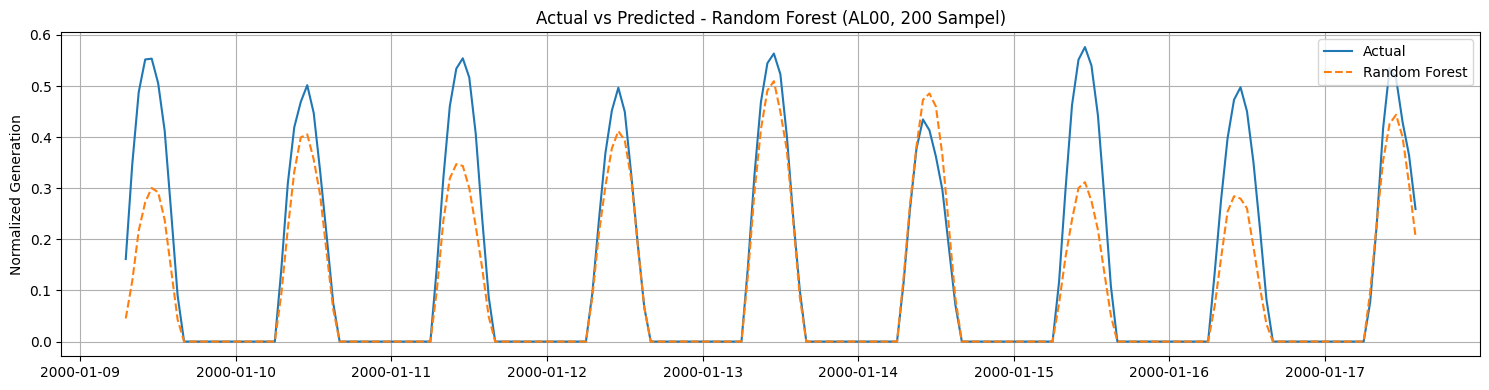

In [41]:
# Actual vs Predicted
plt.figure(figsize=(15, 4))
plt.plot(y_test.index[:200], y_test.values[:200], label='Actual')
plt.plot(y_test.index[:200], y_pred_rf[:200], label='Random Forest', linestyle='--')
plt.title('Actual vs Predicted - Random Forest (AL00, 200 Sampel)')
plt.ylabel('Normalized Generation')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

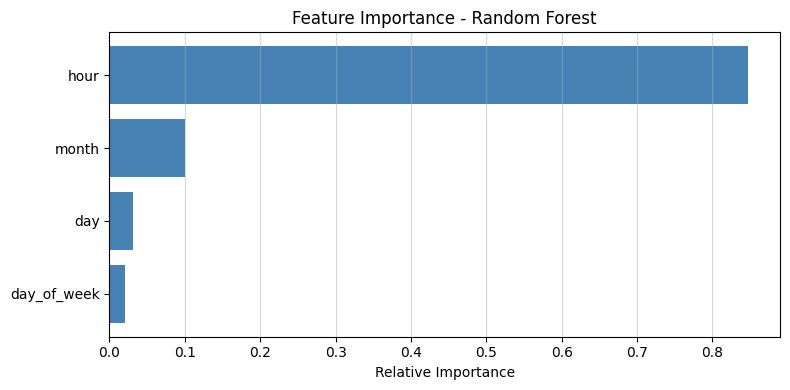

In [42]:
# Feature Importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 4))
plt.barh(range(len(indices)), importances[indices], color='steelblue')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.title('Feature Importance - Random Forest')
plt.xlabel('Relative Importance')
plt.grid(axis='x', alpha=0.5)
plt.tight_layout()
plt.show()

### 5.2 XGBoost

In [43]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42
)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb  = r2_score(y_test, y_pred_xgb)

print(f"XGBoost  ->  MSE: {mse_xgb:.4f}  |  R2: {r2_xgb:.4f}")

XGBoost  ->  MSE: 0.0044  |  R2: 0.9056


### 5.3 Hyperparameter Tuning XGBoost

In [44]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=xgb.XGBRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=10, scoring='r2', cv=3, verbose=0, random_state=42
)
random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best R2 (CV)   :", round(random_search.best_score_, 4))

Best Parameters: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.2, 'colsample_bytree': 1.0}
Best R2 (CV)   : 0.9066


### 5.4 XGBoost dengan Lag Feature

In [45]:
def train_lag_model(region_name, df_clean, base_features):
    data = df_clean[[region_name] + base_features].copy()
    data[region_name] = pd.to_numeric(data[region_name], errors='coerce').fillna(0)

    # Clipping outlier ekstrem pada persentil ke-99
    upper = data[region_name].quantile(0.99)
    if upper > 0:
        data[region_name] = data[region_name].clip(upper=upper * 1.5)

    # Lag feature: nilai generasi 1 jam sebelumnya
    data['lag_1'] = data[region_name].shift(1).fillna(0)

    # Filter jam siang untuk fokus pada periode produksi aktif (06.00-20.00)
    data = data[(data['hour'] >= 6) & (data['hour'] <= 20)]

    model_features = base_features + ['lag_1']
    X = data[model_features]
    y = data[region_name]

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=42, shuffle=False
    )

    model = xgb.XGBRegressor(
        n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42
    )
    model.fit(X_tr, y_tr)

    preds = model.predict(X_te)
    return {
        'Region': region_name,
        'MSE': mean_squared_error(y_te, preds),
        'R2': r2_score(y_te, preds),
        'model': model,
        'X_test': X_te,
        'y_test': y_te
    }

result_al00 = train_lag_model('AL00', df_clean, base_features)
print(f"XGBoost + Lag (AL00)  ->  MSE: {result_al00['MSE']:.4f}  |  R2: {result_al00['R2']:.4f}")

XGBoost + Lag (AL00)  ->  MSE: 0.0003  |  R2: 0.9936


#### Plot Distribusi Data Train & Test — XGBoost

Visualisasi pembagian data temporal 80:20 yang digunakan untuk melatih model XGBoost dengan lag feature.

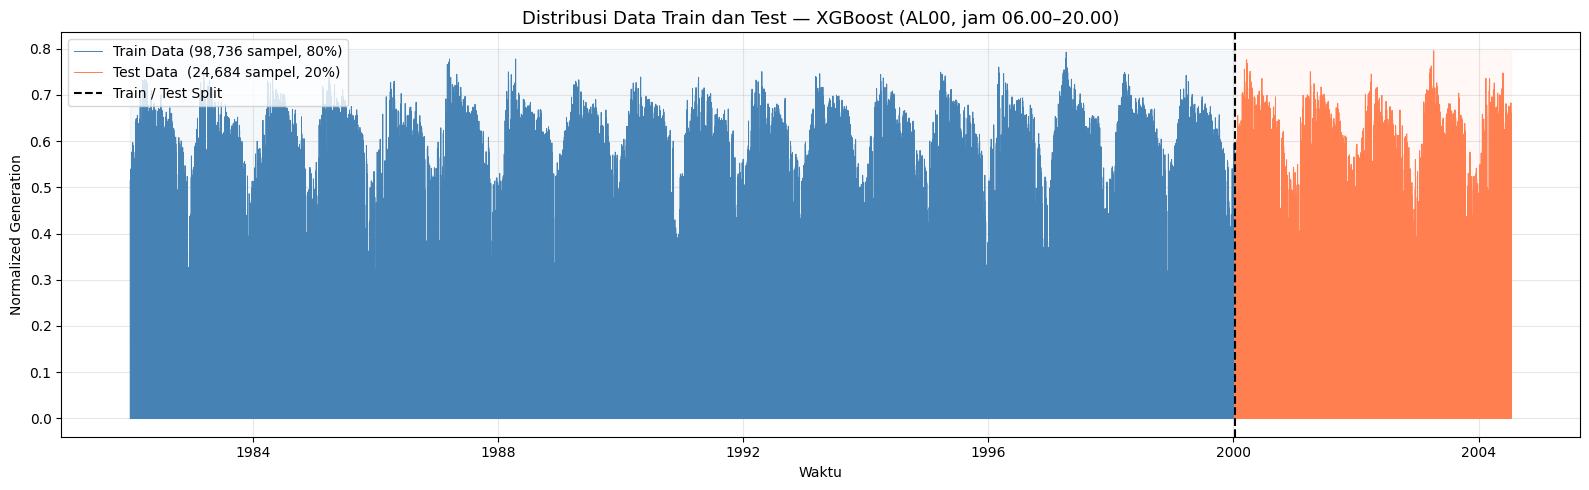

Periode Train : 1982-01-01 s.d. 2000-01-09
Periode Test  : 2000-01-09  s.d. 2004-07-11
Jumlah Train  : 98,736 sampel
Jumlah Test   : 24,684 sampel


In [46]:
# ============================================================
# VISUALISASI SPLIT DATA TRAIN DAN TEST — XGBoost (AL00)
# ============================================================

# Rekonstruksi data yang sama dengan train_lag_model untuk visualisasi split
_vis = df_clean[['AL00'] + base_features].copy()
_vis['AL00'] = pd.to_numeric(_vis['AL00'], errors='coerce').fillna(0)
_upper = _vis['AL00'].quantile(0.99)
_vis['AL00'] = _vis['AL00'].clip(upper=_upper * 1.5)
_vis['lag_1'] = _vis['AL00'].shift(1).fillna(0)
_vis = _vis[(_vis['hour'] >= 6) & (_vis['hour'] <= 20)]

_split = int(len(_vis) * 0.8)
_train = _vis.iloc[:_split]
_test  = _vis.iloc[_split:]

plt.figure(figsize=(16, 5))
plt.plot(_train.index, _train['AL00'], color='steelblue', linewidth=0.7,
         label=f'Train Data ({len(_train):,} sampel, 80%)')
plt.plot(_test.index,  _test['AL00'],  color='coral',     linewidth=0.7,
         label=f'Test Data  ({len(_test):,} sampel, 20%)')
plt.axvline(x=_train.index[-1], color='black', linestyle='--', linewidth=1.5,
            label='Train / Test Split')
plt.fill_betweenx([_vis['AL00'].min(), _vis['AL00'].max()],
                   _train.index[0], _train.index[-1], alpha=0.05, color='steelblue')
plt.fill_betweenx([_vis['AL00'].min(), _vis['AL00'].max()],
                   _test.index[0],  _test.index[-1],  alpha=0.05, color='coral')
plt.title('Distribusi Data Train dan Test — XGBoost (AL00, jam 06.00–20.00)', fontsize=13)
plt.xlabel('Waktu')
plt.ylabel('Normalized Generation')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Periode Train : {_train.index.min().date()} s.d. {_train.index.max().date()}")
print(f"Periode Test  : {_test.index.min().date()}  s.d. {_test.index.max().date()}")
print(f"Jumlah Train  : {len(_train):,} sampel")
print(f"Jumlah Test   : {len(_test):,} sampel")

### 5.5 LSTM (Deep Learning)

In [47]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler

target_region = 'AL00'
target_data = pd.to_numeric(df_clean[target_region], errors='coerce').fillna(0).values.reshape(-1, 1)

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(target_data)

def create_sequences(data, seq_length=24):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

X_seq, y_seq = create_sequences(scaled_data)
train_size = int(len(X_seq) * 0.8)

X_train_lstm = X_seq[:train_size]
X_test_lstm  = X_seq[train_size:]
y_train_lstm = y_seq[:train_size]
y_test_lstm  = y_seq[train_size:]

lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(24, 1)),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')
print("Melatih LSTM...")
history = lstm_model.fit(
    X_train_lstm, y_train_lstm,
    epochs=20, batch_size=64,
    validation_split=0.1, verbose=1
)

Melatih LSTM...
Epoch 1/20
2222/2222 ━━━━━━━━━━━━━━━━━━━━ 76s 32ms/step - loss: 0.0052 - val_loss: 9.6382e-04
Epoch 2/20
2222/2222 ━━━━━━━━━━━━━━━━━━━━ 74s 33ms/step - loss: 0.0014 - val_loss: 7.0246e-04
Epoch 3/20
2222/2222 ━━━━━━━━━━━━━━━━━━━━ 71s 32ms/step - loss: 0.0011 - val_loss: 6.3758e-04
Epoch 4/20
2222/2222 ━━━━━━━━━━━━━━━━━━━━ 72s 33ms/step - loss: 0.0010 - val_loss: 4.7969e-04
Epoch 5/20
2222/2222 ━━━━━━━━━━━━━━━━━━━━ 70s 32ms/step - loss: 9.6979e-04 - val_loss: 3.7115e-04
Epoch 6/20
2222/2222 ━━━━━━━━━━━━━━━━━━━━ 73s 33ms/step - loss: 9.2157e-04 - val_loss: 3.4669e-04
Epoch 7/20
2222/2222 ━━━━━━━━━━━━━━━━━━━━ 80s 32ms/step - loss: 8.9687e-04 - val_loss: 3.7116e-04
Epoch 8/20
2222/2222 ━━━━━━━━━━━━━━━━━━━━ 81s 32ms/step - loss: 8.6853e-04 - val_loss: 3.4063e-04
Epoch 9/20
2222/2222 ━━━━━━━━━━━━━━━━━━━━ 83s 32ms/step - loss: 8.5056e-04 - val_loss: 3.5936e-04
Epoch 10/20
2222/2222 ━━━━━━━━━━━━━━━━━━━━ 70s 31ms/step - loss: 8.3569e-04 - val_loss: 3.2949e-04
Epoch 11/20
2222/22

1235/1235 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step
LSTM  ->  MSE: 0.0003  |  R2: 0.9954


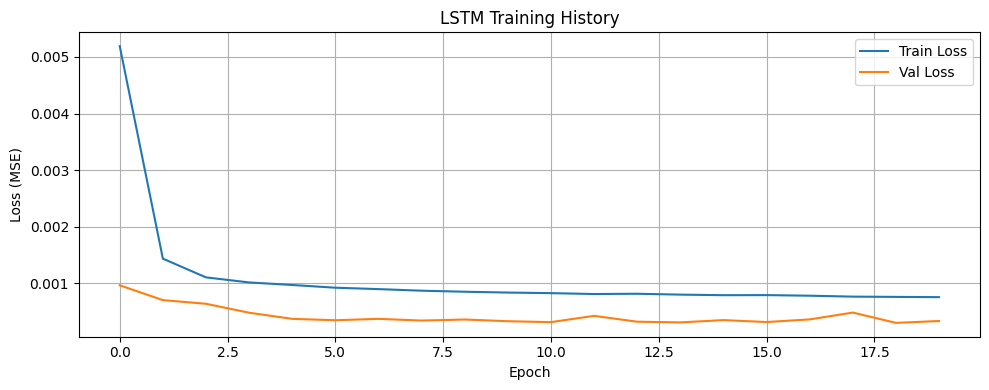

In [48]:
# Evaluasi LSTM
lstm_preds = lstm_model.predict(X_test_lstm)
lstm_mse   = mean_squared_error(y_test_lstm, lstm_preds)
lstm_r2    = r2_score(y_test_lstm, lstm_preds)

print(f"LSTM  ->  MSE: {lstm_mse:.4f}  |  R2: {lstm_r2:.4f}")

# Training History
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('LSTM Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 6. Evaluasi dan Perbandingan Model

Perbandingan Performa Model (AL00):


,Model,MSE,R2 Score
0,Random Forest,0.005904,0.873630
1,XGBoost,0.004410,0.905616
2,XGBoost + Lag,0.000339,0.993557
3,LSTM,0.000338,0.995421


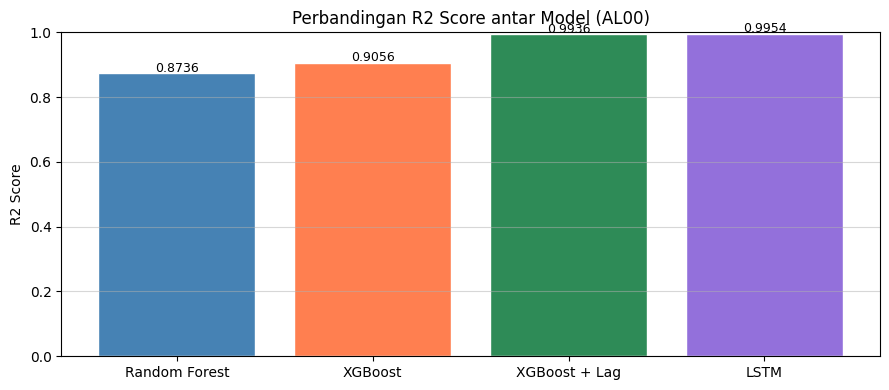

In [49]:
comparison_df = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'XGBoost + Lag', 'LSTM'],
    'MSE':      [mse_rf, mse_xgb, result_al00['MSE'], lstm_mse],
    'R2 Score': [r2_rf,  r2_xgb,  result_al00['R2'],  lstm_r2]
})

print("Perbandingan Performa Model (AL00):")
display(comparison_df)

colors = ['steelblue', 'coral', 'seagreen', 'mediumpurple']
plt.figure(figsize=(9, 4))
bars = plt.bar(comparison_df['Model'], comparison_df['R2 Score'], color=colors, edgecolor='white')
for bar, val in zip(bars, comparison_df['R2 Score']):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.005, f"{val:.4f}", ha='center', fontsize=9)
plt.title('Perbandingan R2 Score antar Model (AL00)')
plt.ylabel('R2 Score')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

## 7. Scaling Model ke Seluruh Wilayah

Model XGBoost + Lag diaplikasikan ke semua 179+ wilayah secara otomatis.

In [21]:
import time

exclude_cols = ['hour', 'day', 'month', 'day_of_week']
regions_to_process = [col for col in df_clean.columns if col not in exclude_cols]

all_results = []
start = time.time()

print(f"Memproses {len(regions_to_process)} wilayah...")
for i, region in enumerate(regions_to_process):
    try:
        res = train_lag_model(region, df_clean, base_features)
        all_results.append({'Region': res['Region'], 'MSE': res['MSE'], 'R2': res['R2']})
        if (i + 1) % 40 == 0:
            print(f"  Selesai: {i+1}/{len(regions_to_process)}")
    except Exception:
        continue

final_df = pd.DataFrame(all_results)
print(f"\nSelesai dalam {(time.time()-start)/60:.1f} menit.")
print("\nRingkasan R2 Score:")
display(final_df['R2'].describe())

Memproses 179 wilayah...
  Selesai: 40/179
  Selesai: 80/179
  Selesai: 120/179
  Selesai: 160/179

Selesai dalam 0.9 menit.

Ringkasan R2 Score:


,R2
count,179.000000
mean,0.989740
std,0.006901
min,0.970835
25%,0.984033
50%,0.990853
75%,0.995687
max,0.999750


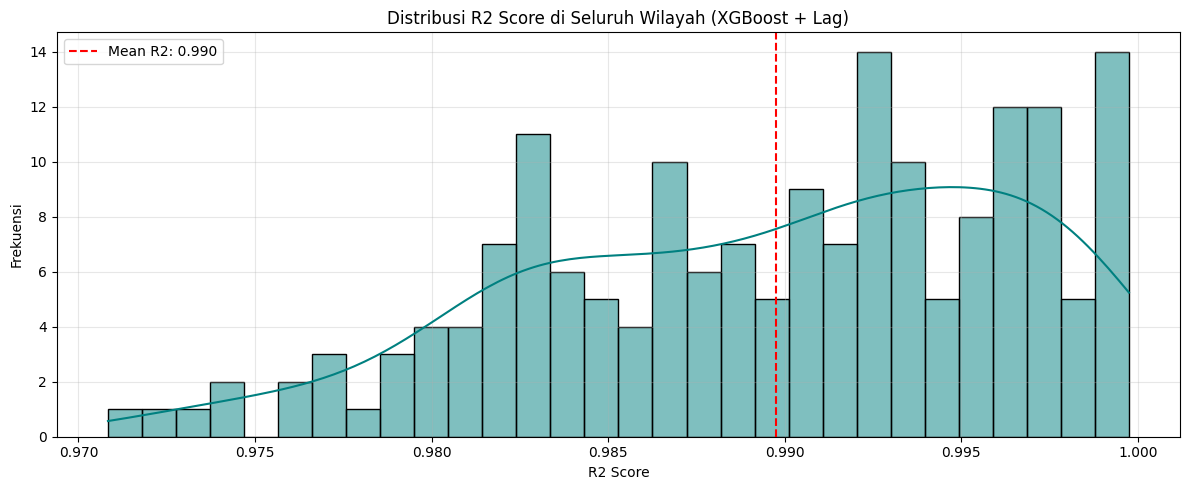

Top 5 Wilayah:


,Region,MSE,R2
34,EG00,0.000024,0.999750
95,LY02,0.000030,0.999671
29,DZ00,0.000029,0.999646
93,LY00,0.000032,0.999630
96,LY03,0.000044,0.999493



Bottom 5 Wilayah:


,Region,MSE,R2
110,NL02,0.001302,0.970835
177,UKNI,0.001404,0.972362
109,NL01,0.001191,0.973485
8,BE02,0.001250,0.973842
91,LU00,0.001337,0.974289


In [22]:
# Distribusi R2 Score seluruh wilayah
plt.figure(figsize=(12, 5))
sns.histplot(final_df['R2'], bins=30, kde=True, color='teal')
plt.axvline(final_df['R2'].mean(), color='red', linestyle='--',
            label=f"Mean R2: {final_df['R2'].mean():.3f}")
plt.title('Distribusi R2 Score di Seluruh Wilayah (XGBoost + Lag)')
plt.xlabel('R2 Score')
plt.ylabel('Frekuensi')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Top 5 Wilayah:")
display(final_df.sort_values('R2', ascending=False).head())

print("\nBottom 5 Wilayah:")
display(final_df.sort_values('R2').head())

## 7.1 Actual vs Predicted XGBoost — Multi-Wilayah

Visualisasi perbandingan nilai aktual dan prediksi model XGBoost + Lag Feature pada AL00 dan wilayah-wilayah lain di luar Albania, untuk memvalidasi generalisasi model.

Wilayah yang divisualisasi: ['EG00', 'LY02', 'DZ00', 'LY00']



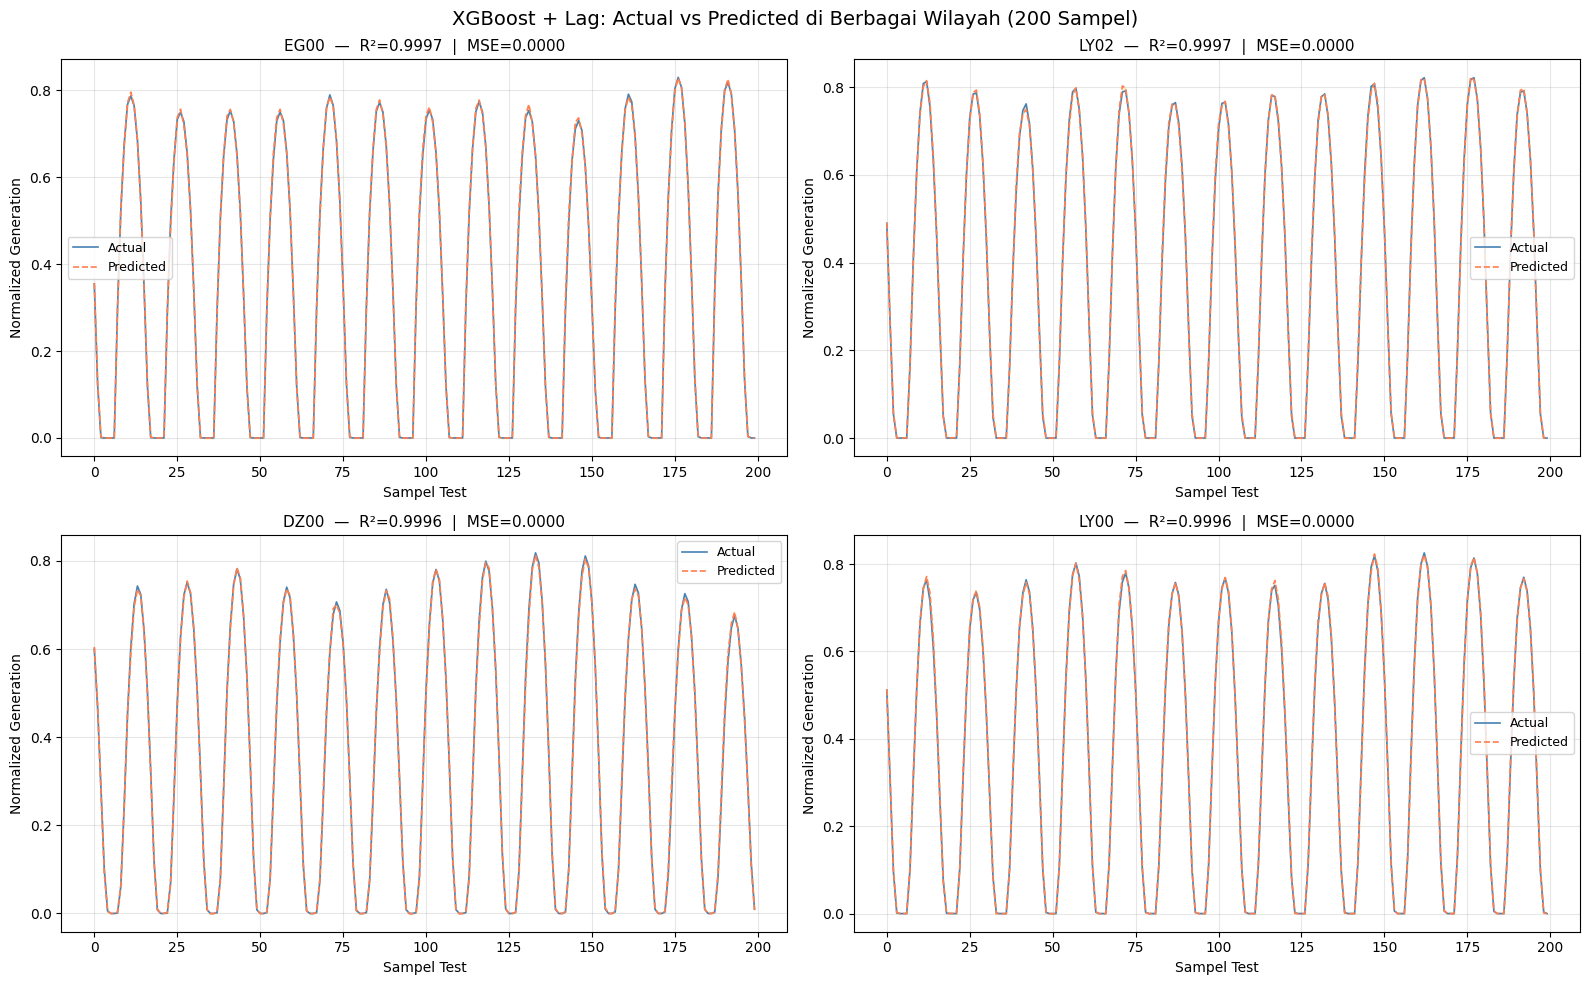

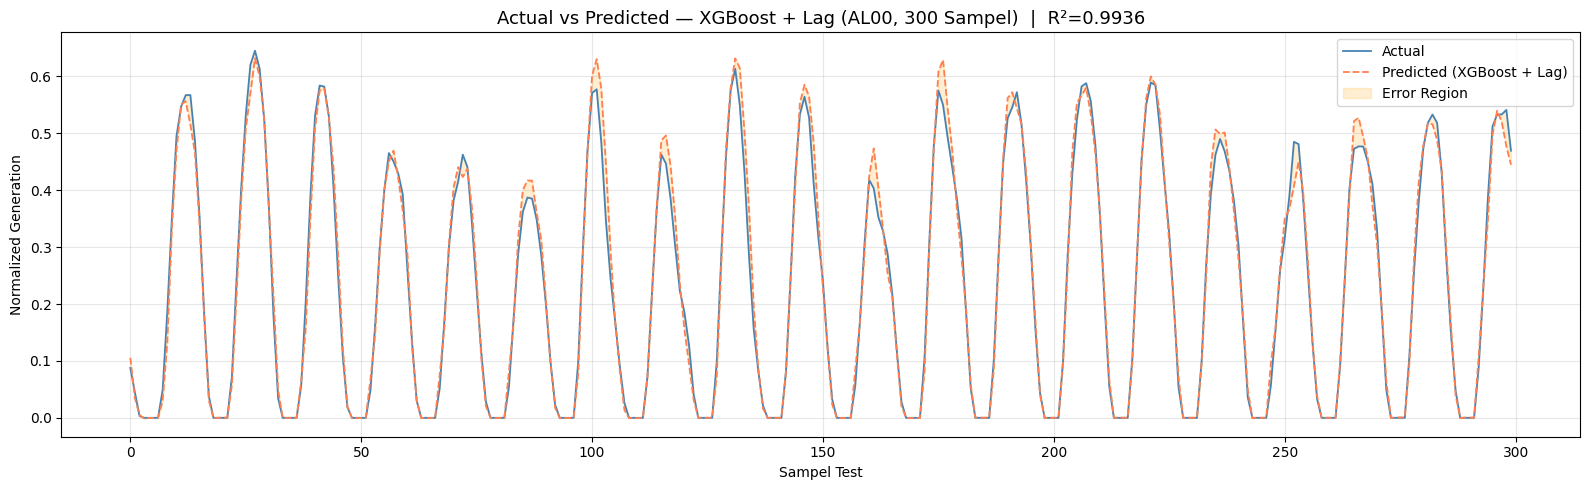

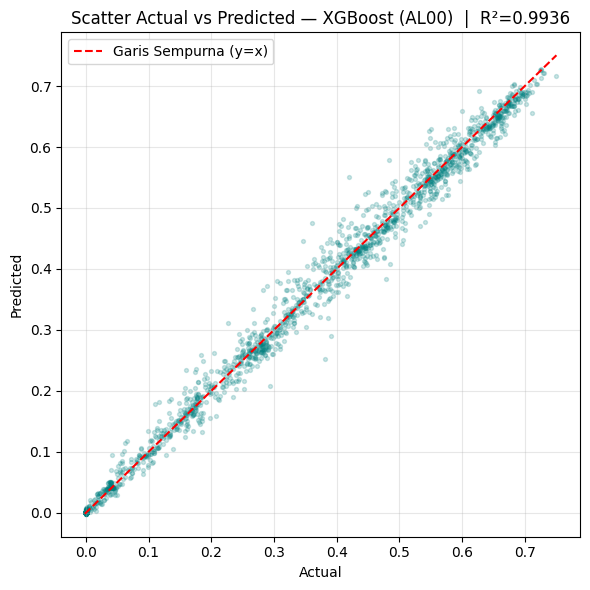


📊 Evaluasi XGBoost + Lag (AL00):
   R²  : 0.9936
   MSE : 0.0004
   MAE : 0.0117


In [23]:
# ============================================================
# ACTUAL vs PREDICTED — XGBoost + Lag, MULTI-WILAYAH
# ============================================================

# Pilih 4 wilayah representatif di luar AL00 (ambil dari top final_df jika tersedia)
try:
    top_regions = final_df.sort_values('R2', ascending=False)['Region'].tolist()
    sample_regions = [r for r in top_regions if r != 'AL00'][:4]
except NameError:
    sample_regions = ['DE00', 'EG00', 'ES00', 'FR00']

print(f"Wilayah yang divisualisasi: {sample_regions}\n")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, region in zip(axes, sample_regions):
    _res = train_lag_model(region, df_clean, base_features)
    _y_true = _res['y_test'].values
    _y_pred = _res['model'].predict(_res['X_test'])
    n_show = min(200, len(_y_true))

    ax.plot(range(n_show), _y_true[:n_show], label='Actual',    color='steelblue', linewidth=1.2)
    ax.plot(range(n_show), _y_pred[:n_show], label='Predicted', color='coral', linewidth=1.2, linestyle='--')
    ax.fill_between(range(n_show), _y_true[:n_show], _y_pred[:n_show], alpha=0.15, color='orange')
    ax.set_title(f'{region}  —  R²={_res["R2"]:.4f}  |  MSE={_res["MSE"]:.4f}', fontsize=11)
    ax.set_xlabel('Sampel Test')
    ax.set_ylabel('Normalized Generation')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('XGBoost + Lag: Actual vs Predicted di Berbagai Wilayah (200 Sampel)', fontsize=14)
plt.tight_layout()
plt.show()

# ── AL00: Line plot Actual vs Predicted (lebih detail) ──────
_al = train_lag_model('AL00', df_clean, base_features)
_yt = _al['y_test'].values
_yp = _al['model'].predict(_al['X_test'])
n = 300

plt.figure(figsize=(16, 5))
plt.plot(range(n), _yt[:n], label='Actual',                      color='steelblue', linewidth=1.3)
plt.plot(range(n), _yp[:n], label='Predicted (XGBoost + Lag)',   color='coral',     linewidth=1.3, linestyle='--')
plt.fill_between(range(n), _yt[:n], _yp[:n], alpha=0.18, color='orange', label='Error Region')
plt.title(f'Actual vs Predicted — XGBoost + Lag (AL00, 300 Sampel)  |  R²={_al["R2"]:.4f}', fontsize=13)
plt.xlabel('Sampel Test')
plt.ylabel('Normalized Generation')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── Scatter Plot Actual vs Predicted ────────────────────────
n_scatter = min(2000, len(_yt))
plt.figure(figsize=(6, 6))
plt.scatter(_yt[:n_scatter], _yp[:n_scatter], alpha=0.2, s=8, color='teal')
_min, _max = min(_yt.min(), _yp.min()), max(_yt.max(), _yp.max())
plt.plot([_min, _max], [_min, _max], 'r--', linewidth=1.5, label='Garis Sempurna (y=x)')
plt.title(f'Scatter Actual vs Predicted — XGBoost (AL00)  |  R²={_al["R2"]:.4f}')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(_yt, _yp)
print(f"\n📊 Evaluasi XGBoost + Lag (AL00):")
print(f"   R²  : {_al['R2']:.4f}")
print(f"   MSE : {_al['MSE']:.4f}")
print(f"   MAE : {mae:.4f}")

## 8. Deteksi Anomali dengan Isolation Forest

Isolation Forest mendeteksi pola pembangkitan yang menyimpang dari pola normal, berguna untuk mengidentifikasi gangguan peralatan atau cuaca ekstrem.

In [24]:
from sklearn.ensemble import IsolationForest

data_anomaly = df_clean[['AL00', 'hour', 'month']].copy()
data_anomaly['AL00'] = pd.to_numeric(data_anomaly['AL00'], errors='coerce').fillna(0)

iso_forest = IsolationForest(contamination=0.01, random_state=42)
data_anomaly['anomaly'] = iso_forest.fit_predict(
    data_anomaly[['AL00', 'hour', 'month']]
)

anomalies = data_anomaly[data_anomaly['anomaly'] == -1]
print(f"Anomali terdeteksi: {len(anomalies)} dari {len(data_anomaly)} titik data "
      f"({len(anomalies)/len(data_anomaly)*100:.1f}%)")

Anomali terdeteksi: 237 dari 23656 titik data (1.0%)


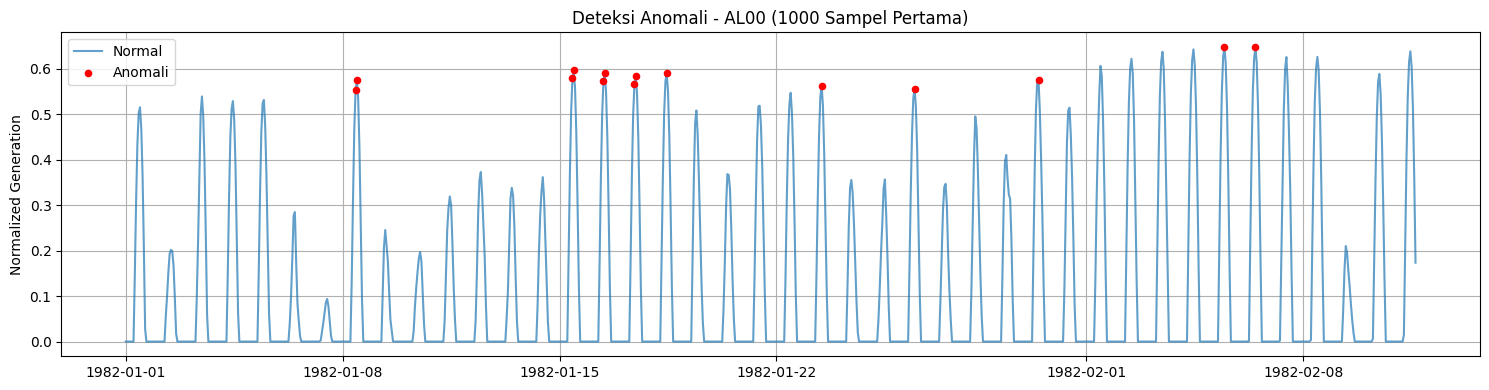

In [25]:
# Visualisasi anomali pada deret waktu
plt.figure(figsize=(15, 4))
plt.plot(data_anomaly.index[:1000], data_anomaly['AL00'][:1000], alpha=0.7, label='Normal')
anom_in_range = anomalies[anomalies.index.isin(data_anomaly.index[:1000])]
plt.scatter(anom_in_range.index, anom_in_range['AL00'],
            color='red', label='Anomali', zorder=5, s=20)
plt.title('Deteksi Anomali - AL00 (1000 Sampel Pertama)')
plt.ylabel('Normalized Generation')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

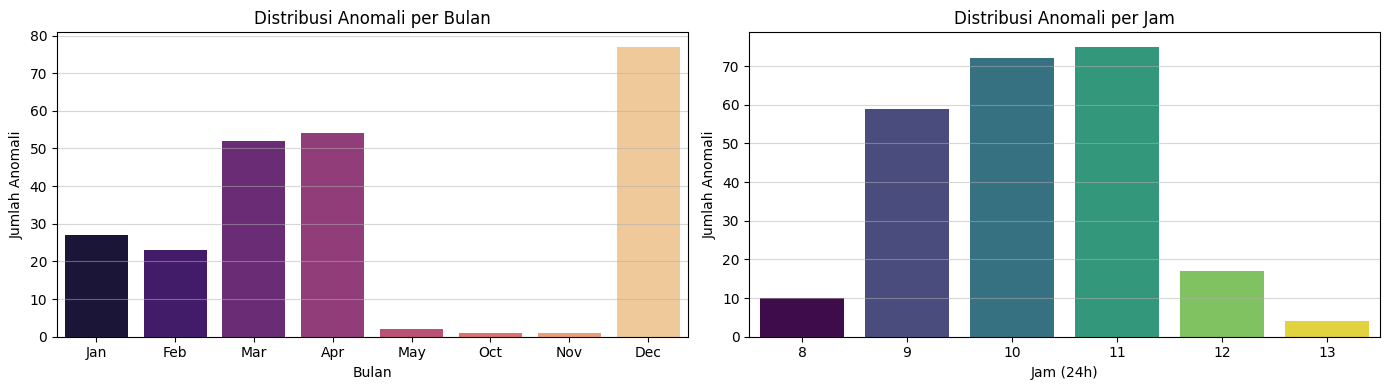

In [26]:
# Distribusi anomali per bulan
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

anomaly_by_month = anomalies.groupby('month').size().reset_index(name='count')
anomaly_by_month['month_name'] = anomaly_by_month['month'].map(month_names)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.barplot(x='month_name', y='count', data=anomaly_by_month,
            hue='month_name', palette='magma', legend=False, ax=axes[0])
axes[0].set_title('Distribusi Anomali per Bulan')
axes[0].set_xlabel('Bulan')
axes[0].set_ylabel('Jumlah Anomali')
axes[0].grid(axis='y', alpha=0.5)

anomaly_by_hour = anomalies.groupby('hour').size().reset_index(name='count')
sns.barplot(x='hour', y='count', data=anomaly_by_hour,
            hue='hour', palette='viridis', legend=False, ax=axes[1])
axes[1].set_title('Distribusi Anomali per Jam')
axes[1].set_xlabel('Jam (24h)')
axes[1].set_ylabel('Jumlah Anomali')
axes[1].grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.show()

## 9. Multi-Step Recursive Forecasting

Model memprediksi 24 jam ke depan secara rekursif. Setiap prediksi diumpankan kembali sebagai lag_1 untuk langkah berikutnya.

In [27]:
import joblib

# Latih model final untuk EG00
res_eg00 = train_lag_model('EG00', df_clean, base_features)
final_model = res_eg00['model']

joblib.dump(final_model, '/content/solar_model_eg00.joblib')
print(f"Model EG00 disimpan.  R2: {res_eg00['R2']:.4f}")

Model EG00 disimpan.  R2: 0.9997


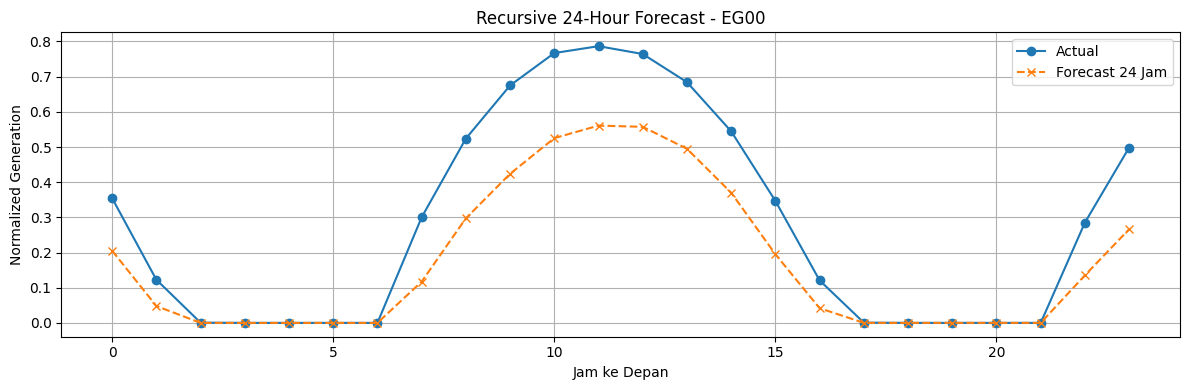

In [28]:
def forecast_24h(model, start_data, initial_lag):
    forecasts = []
    current_lag = initial_lag

    for i in range(len(start_data)):
        row = start_data.iloc[[i]].copy()
        row['lag_1'] = current_lag
        pred = max(0, model.predict(row)[0])
        forecasts.append(pred)
        current_lag = pred

    return forecasts

X_te_eg = res_eg00['X_test']
y_te_eg = res_eg00['y_test']

predicted_24h = forecast_24h(final_model, X_te_eg.head(24), y_te_eg.iloc[0])

plt.figure(figsize=(12, 4))
plt.plot(range(24), y_te_eg.iloc[:24].values, label='Actual', marker='o')
plt.plot(range(24), predicted_24h, label='Forecast 24 Jam', linestyle='--', marker='x')
plt.title('Recursive 24-Hour Forecast - EG00')
plt.xlabel('Jam ke Depan')
plt.ylabel('Normalized Generation')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 10. Export Hasil

In [29]:
final_df.to_csv('/content/solar_model_performance.csv', index=False)
final_df.to_excel('/content/solar_model_performance.xlsx', index=False, engine='openpyxl')

print("Hasil disimpan ke:")
print("  /content/solar_model_performance.csv")
print("  /content/solar_model_performance.xlsx")
print("\nRingkasan akhir:")
display(final_df.describe())

Hasil disimpan ke:
  /content/solar_model_performance.csv
  /content/solar_model_performance.xlsx

Ringkasan akhir:


,MSE,R2
count,179.000000,179.000000
mean,0.000535,0.989740
std,0.000312,0.006901
min,0.000024,0.970835
25%,0.000282,0.984033
50%,0.000522,0.990853
75%,0.000747,0.995687
max,0.001404,0.999750


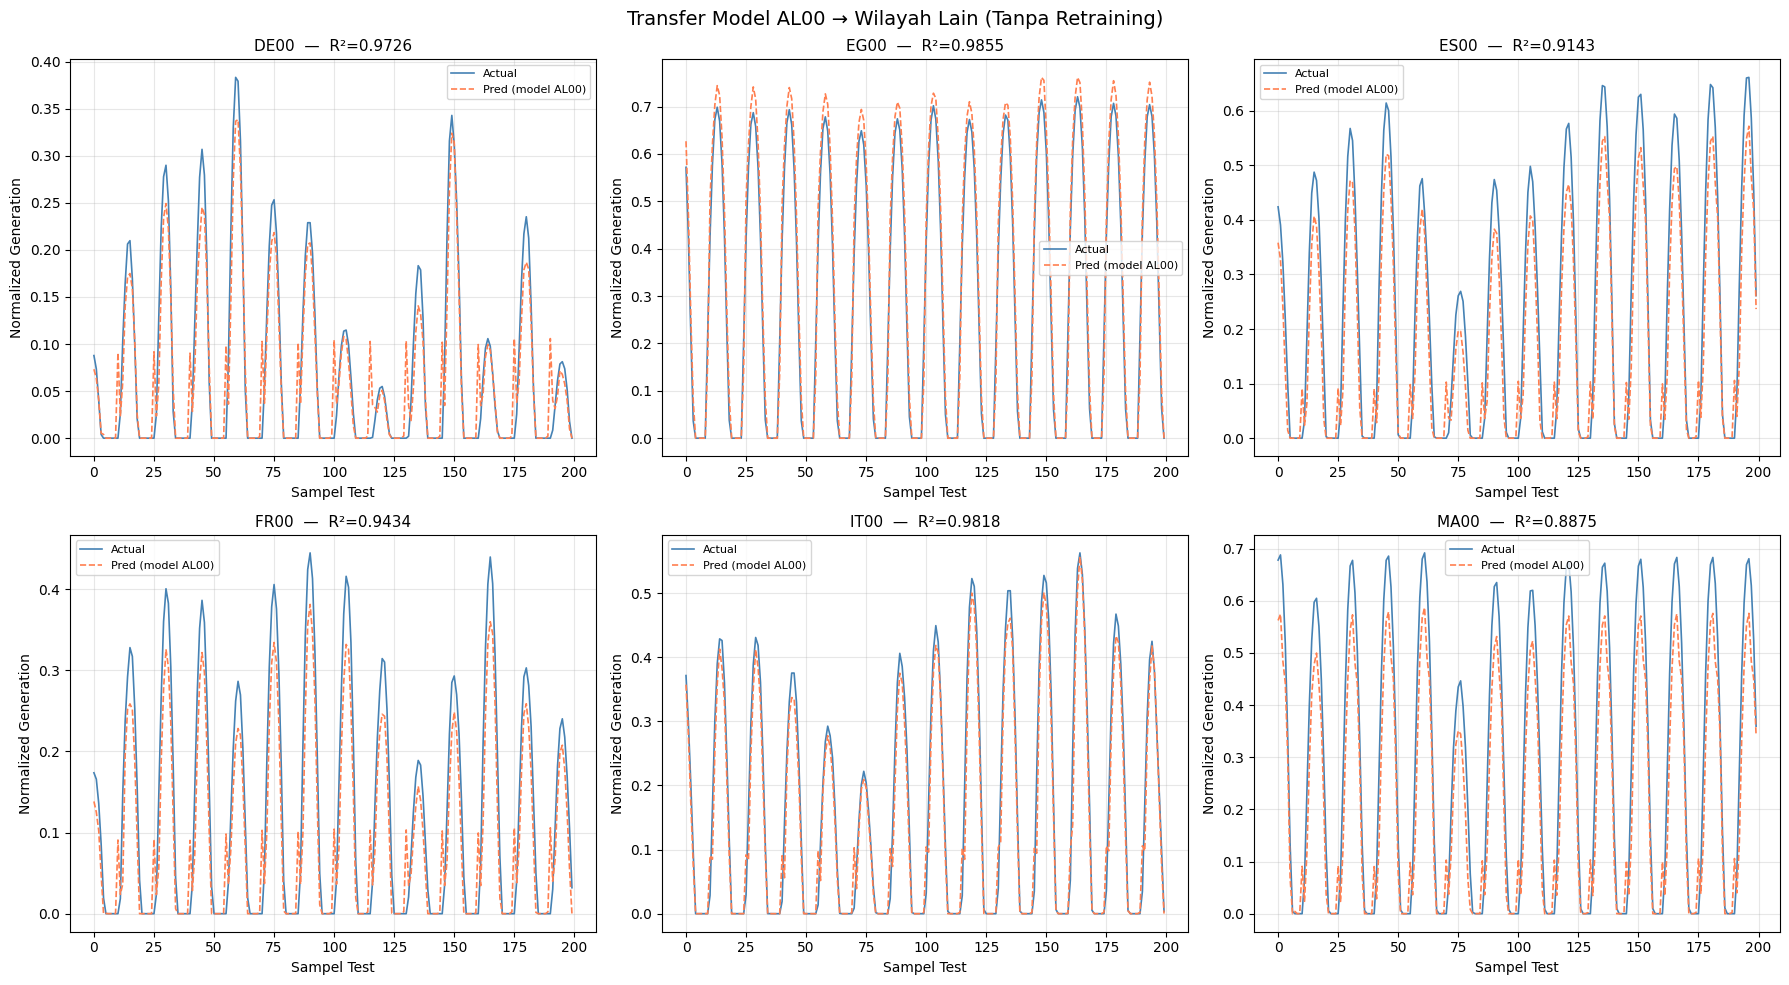

Perbandingan R² — Transfer (AL00) vs Retrained per Wilayah:



,Region,R2_Transfer,MSE_Transfer,R2_Retrained,Gap
0,DE00,0.9726,0.0011,0.9927,0.0201
1,EG00,0.9855,0.0013,0.9997,0.0143
2,ES00,0.9143,0.0054,0.9968,0.0825
3,FR00,0.9434,0.0026,0.9957,0.0522
4,IT00,0.9818,0.0009,0.9970,0.0152
5,MA00,0.8875,0.0087,0.9995,0.1119


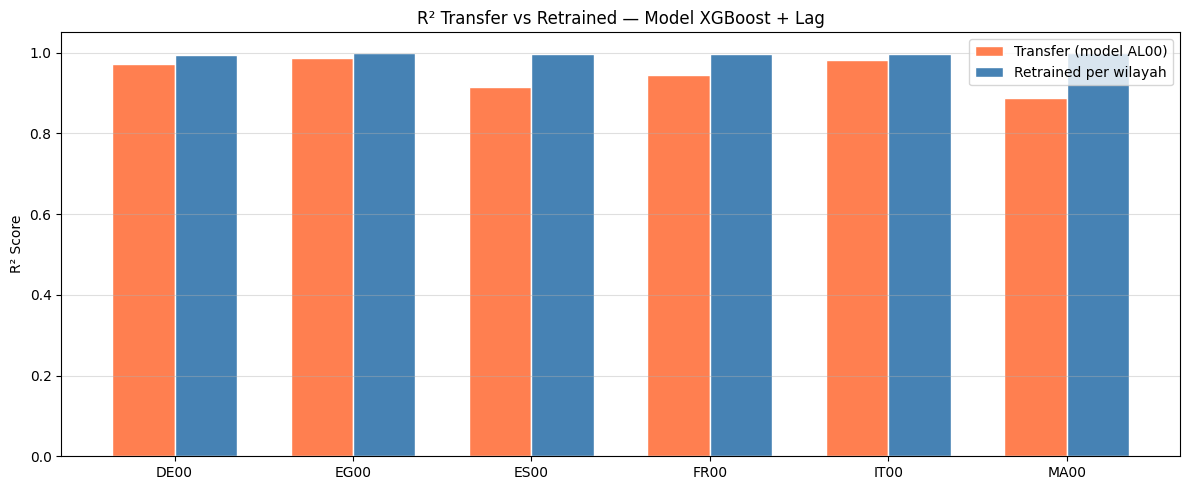

In [50]:
# ============================================================
# GENERALISASI MODEL AL00 KE WILAYAH LAIN (TANPA RETRAINING)
# Cross-Region Transfer Test — XGBoost + Lag
# ============================================================

# Latih model HANYA dari AL00
res_al00 = train_lag_model('AL00', df_clean, base_features)
model_al00 = res_al00['model']

# Wilayah target yang mau diuji (pilih beberapa yang representatif)
test_regions = ['DE00', 'EG00', 'ES00', 'FR00', 'IT00', 'MA00']

transfer_results = []

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, region in zip(axes, test_regions):
    # Siapkan data wilayah target (format sama dengan train_lag_model)
    data_r = df_clean[[region] + base_features].copy()
    data_r[region] = pd.to_numeric(data_r[region], errors='coerce').fillna(0)
    upper = data_r[region].quantile(0.99)
    data_r[region] = data_r[region].clip(upper=upper * 1.5)
    data_r['lag_1'] = data_r[region].shift(1).fillna(0)
    data_r = data_r[(data_r['hour'] >= 6) & (data_r['hour'] <= 20)]

    model_features = base_features + ['lag_1']
    X_r = data_r[model_features]
    y_r = data_r[region]

    # Ambil 20% terakhir sebagai test set (konsisten dengan split)
    split = int(len(X_r) * 0.8)
    X_te_r = X_r.iloc[split:]
    y_te_r = y_r.iloc[split:]

    # PREDIKSI langsung pakai model AL00 (tanpa retraining!)
    y_pred_transfer = model_al00.predict(X_te_r)
    y_pred_transfer = np.clip(y_pred_transfer, 0, None)

    r2_transfer  = r2_score(y_te_r, y_pred_transfer)
    mse_transfer = mean_squared_error(y_te_r, y_pred_transfer)
    transfer_results.append({'Region': region, 'R2_Transfer': r2_transfer, 'MSE_Transfer': mse_transfer})

    # Plot
    n = min(200, len(y_te_r))
    ax.plot(range(n), y_te_r.values[:n],    label='Actual',           color='steelblue', linewidth=1.2)
    ax.plot(range(n), y_pred_transfer[:n],   label='Pred (model AL00)', color='coral',    linewidth=1.2, linestyle='--')
    ax.set_title(f'{region}  —  R²={r2_transfer:.4f}', fontsize=11)
    ax.set_xlabel('Sampel Test')
    ax.set_ylabel('Normalized Generation')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Transfer Model AL00 → Wilayah Lain (Tanpa Retraining)', fontsize=14)
plt.tight_layout()
plt.show()

# ── Bandingkan: Transfer vs Retrained ──────────────────────
transfer_df = pd.DataFrame(transfer_results)

# Ambil R2 wilayah yang sama dari final_df (retrained)
if 'final_df' in dir():
    merged = transfer_df.merge(
        final_df[final_df['Region'].isin(test_regions)][['Region','R2']].rename(columns={'R2': 'R2_Retrained'}),
        on='Region', how='left'
    )
    merged['Gap'] = merged['R2_Retrained'] - merged['R2_Transfer']

    print("Perbandingan R² — Transfer (AL00) vs Retrained per Wilayah:\n")
    display(merged.round(4))

    # Bar chart perbandingan
    x = np.arange(len(merged))
    w = 0.35
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x - w/2, merged['R2_Transfer'],  w, label='Transfer (model AL00)', color='coral',     edgecolor='white')
    ax.bar(x + w/2, merged['R2_Retrained'], w, label='Retrained per wilayah', color='steelblue', edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(merged['Region'])
    ax.set_ylabel('R² Score')
    ax.set_title('R² Transfer vs Retrained — Model XGBoost + Lag')
    ax.legend()
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.4)
    plt.tight_layout()
    plt.show()
else:
    print("R² Transfer per wilayah:")
    display(transfer_df.round(4))